In [10]:
import os
import h5py
import numpy as np

# Create synthetic GMI and ENV files if they don't exist
GMI_FILE = 'data/sample_gmi.h5'
ENV_FILE = 'data/sample_env.h5'

# Need to match the ray dimension from the actual DPR file
# DPR typically has 49 rays, so let's create ENV with compatible dimensions
if not os.path.exists(GMI_FILE):
    print(f"Creating synthetic GMI file: {GMI_FILE}")
    with h5py.File(GMI_FILE, 'w') as f:
        # shape: (nscan, nchannels, npixels)
        f.create_dataset('/S1/Tb', data=np.ones((1, 9, 221)) + 250.0)

if not os.path.exists(ENV_FILE):
    print(f"Creating synthetic ENV file: {ENV_FILE}")
    with h5py.File(ENV_FILE, 'w') as f:
        # shape: (nbin, nray, nscan) to match DPR structure
        # Use 176 bins, 49 rays, 1 scan
        f.create_dataset('/ENV/airTemperature', data=np.tile(np.linspace(290, 250, 176).reshape(176, 1, 1), (1, 49, 1)))
        f.create_dataset('/ENV/airPressure', data=np.tile(np.linspace(101300, 20000, 176).reshape(176, 1, 1), (1, 49, 1)))
        f.create_dataset('/ENV/waterVapor', data=np.ones((176, 49, 1)) * 0.01)

# Now run the combined algorithm
from src.run_combined import run_one_footprint
updated, fwd = run_one_footprint(
    'data/GPM_2ADPR.07.HDF5',
    GMI_FILE,
    ENV_FILE,
    scan_idx=0,
    ray_idx=10
)
print("\n✓ Pipeline completed successfully!")
print(f"✓ Ensemble size: {len(updated)} members")
print(f"✓ Updated ensemble keys: {list(updated[0].keys())}")

Reading DPR...
Running Ku Radar Module (ensemble)...
Forward model...
Read observed GMI TB (if available)
Apply ensemble filter using observed TB and PIA/ZKa...
DEBUG filter_module: N=40, nb=176, nch=9
DEBUG filter_module: state_size=537
Pipeline finished; returning updated ensemble.

✓ Pipeline completed successfully!
✓ Ensemble size: 40 members
✓ Updated ensemble keys: ['Dm', 'Nw', 'qv', 'qcld', 'Zcorr', 'kprof', 'R', 'TBsim']
Running Ku Radar Module (ensemble)...
Forward model...
Read observed GMI TB (if available)
Apply ensemble filter using observed TB and PIA/ZKa...
DEBUG filter_module: N=40, nb=176, nch=9
DEBUG filter_module: state_size=537
Pipeline finished; returning updated ensemble.

✓ Pipeline completed successfully!
✓ Ensemble size: 40 members
✓ Updated ensemble keys: ['Dm', 'Nw', 'qv', 'qcld', 'Zcorr', 'kprof', 'R', 'TBsim']


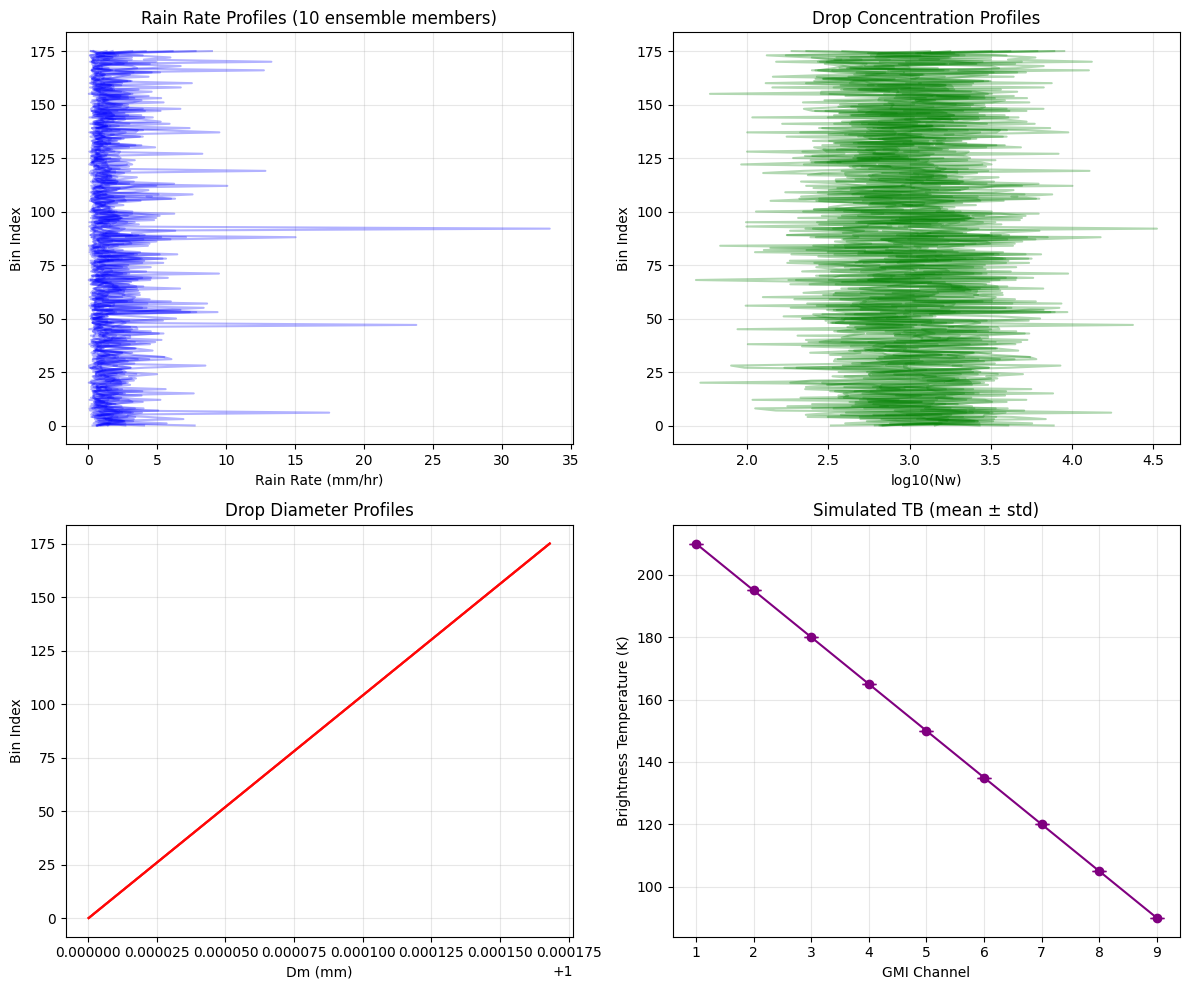


✓ Visualization complete!


In [11]:
# Visualize results
import matplotlib.pyplot as plt

# Plot ensemble results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Rain rate profiles
ax = axes[0, 0]
for i, member in enumerate(updated[:10]):  # Plot first 10 members
    ax.plot(member['R'], range(len(member['R'])), alpha=0.3, color='blue')
ax.set_xlabel('Rain Rate (mm/hr)')
ax.set_ylabel('Bin Index')
ax.set_title('Rain Rate Profiles (10 ensemble members)')
ax.grid(True, alpha=0.3)

# Plot 2: Nw profiles (drop concentration)
ax = axes[0, 1]
for i, member in enumerate(updated[:10]):
    ax.plot(np.log10(member['Nw']), range(len(member['Nw'])), alpha=0.3, color='green')
ax.set_xlabel('log10(Nw)')
ax.set_ylabel('Bin Index')
ax.set_title('Drop Concentration Profiles')
ax.grid(True, alpha=0.3)

# Plot 3: Dm profiles (drop diameter)
ax = axes[1, 0]
for i, member in enumerate(updated[:10]):
    ax.plot(member['Dm'], range(len(member['Dm'])), alpha=0.3, color='red')
ax.set_xlabel('Dm (mm)')
ax.set_ylabel('Bin Index')
ax.set_title('Drop Diameter Profiles')
ax.grid(True, alpha=0.3)

# Plot 4: Simulated brightness temperatures
ax = axes[1, 1]
channels = range(1, 10)
tb_ensemble = np.array([member['TBsim'] for member in updated])
tb_mean = tb_ensemble.mean(axis=0)
tb_std = tb_ensemble.std(axis=0)
ax.errorbar(channels, tb_mean, yerr=tb_std, fmt='o-', capsize=5, color='purple')
ax.set_xlabel('GMI Channel')
ax.set_ylabel('Brightness Temperature (K)')
ax.set_title('Simulated TB (mean ± std)')
ax.grid(True, alpha=0.3)
ax.set_xticks(channels)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete!")

In [12]:
# Display summary statistics
print("=== Ensemble Summary Statistics ===\n")

# Rain rate statistics
rain_rates = np.array([member['R'] for member in updated])
print(f"Rain Rate:")
print(f"  Mean: {rain_rates.mean():.4f} mm/hr")
print(f"  Std:  {rain_rates.std():.4f} mm/hr")
print(f"  Max:  {rain_rates.max():.4f} mm/hr\n")

# Drop concentration
nw_values = np.array([member['Nw'] for member in updated])
print(f"Drop Concentration (Nw):")
print(f"  Mean log10(Nw): {np.log10(nw_values).mean():.2f}")
print(f"  Std log10(Nw):  {np.log10(nw_values).std():.2f}\n")

# Simulated brightness temperatures
tb_ensemble = np.array([member['TBsim'] for member in updated])
print(f"Simulated Brightness Temperatures:")
print(f"  Mean: {tb_ensemble.mean():.2f} K")
print(f"  Std:  {tb_ensemble.std():.2f} K")
print(f"  Range: [{tb_ensemble.min():.2f}, {tb_ensemble.max():.2f}] K\n")

# Forward model outputs
pia_values = np.array([f['PIA'] for f in fwd])
print(f"Path Integrated Attenuation (PIA):")
print(f"  Mean: {pia_values.mean():.4f} dB")
print(f"  Std:  {pia_values.std():.4f} dB")

=== Ensemble Summary Statistics ===

Rain Rate:
  Mean: 1.5385 mm/hr
  Std:  1.8600 mm/hr
  Max:  34.4456 mm/hr

Drop Concentration (Nw):
  Mean log10(Nw): 3.00
  Std log10(Nw):  0.40

Simulated Brightness Temperatures:
  Mean: 150.00 K
  Std:  38.73 K
  Range: [90.00, 210.00] K

Path Integrated Attenuation (PIA):
  Mean: 0.0044 dB
  Std:  0.0000 dB


## Bright Band Analysis

The bright band (BB) is a radar signature of the melting layer where snowflakes transition to raindrops. The GPM DPR Cloud Structure Feature (CSF) product provides:
- **flagBB**: Flag indicating presence of bright band (1 = present, 0 = absent)
- **binBBTop**: Top bin index of bright band
- **binBBBottom**: Bottom bin index of bright band
- **binBBPeak**: Peak bin index of bright band
- **heightBB**: Height of bright band (meters)
- **widthBB**: Width of bright band (meters)
- **qualityBB**: Quality flag for bright band detection

In [15]:
# Extract and display bright band information
import h5py

DPR_FILE = 'data/GPM_2ADPR.07.HDF5'
SCAN_IDX = 758
RAY_IDX = 10

with h5py.File(DPR_FILE, 'r') as f:
    # Read bright band fields
    flagBB = f['/FS/CSF/flagBB'][SCAN_IDX, RAY_IDX]
    
    print("=== Bright Band Information ===\n")
    print(f"Scan Index: {SCAN_IDX}, Ray Index: {RAY_IDX}")
    print(f"\nBright Band Present: {'YES' if flagBB == 1 else 'NO'} (flag={flagBB})")
    
    if flagBB == 1:
        binBBTop = f['/FS/CSF/binBBTop'][SCAN_IDX, RAY_IDX]
        binBBBottom = f['/FS/CSF/binBBBottom'][SCAN_IDX, RAY_IDX]
        binBBPeak = f['/FS/CSF/binBBPeak'][SCAN_IDX, RAY_IDX]
        heightBB = f['/FS/CSF/heightBB'][SCAN_IDX, RAY_IDX]
        widthBB = f['/FS/CSF/widthBB'][SCAN_IDX, RAY_IDX]
        qualityBB = f['/FS/CSF/qualityBB'][SCAN_IDX, RAY_IDX]
        
        print(f"\nBright Band Vertical Extent:")
        print(f"  Top Bin:    {binBBTop}")
        print(f"  Peak Bin:   {binBBPeak}")
        print(f"  Bottom Bin: {binBBBottom}")
        print(f"  Height:     {heightBB:.1f} m")
        print(f"  Width:      {widthBB:.1f} m")
        print(f"  Quality:    {qualityBB}")
        
        # Store for visualization
        bb_info = {
            'top': binBBTop,
            'peak': binBBPeak,
            'bottom': binBBBottom,
            'height': heightBB,
            'width': widthBB
        }
    else:
        print("\nNo bright band detected for this ray.")
        bb_info = None

=== Bright Band Information ===

Scan Index: 758, Ray Index: 10

Bright Band Present: YES (flag=1)

Bright Band Vertical Extent:
  Top Bin:    155
  Peak Bin:   161
  Bottom Bin: 164
  Height:     1894.0 m
  Width:      824.4 m
  Quality:    1


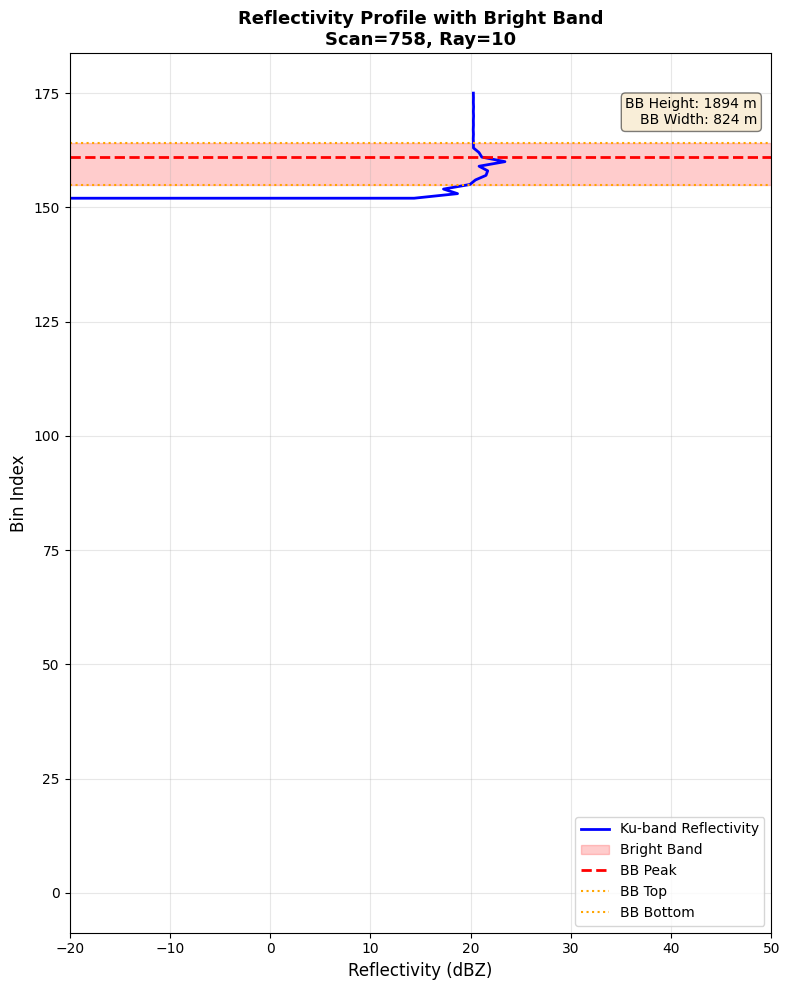


✓ Bright band visualization complete!


In [16]:
# Visualize reflectivity profile with bright band overlay
import matplotlib.pyplot as plt
from src.io import read_dpr_ku

# Read the reflectivity data
ZKu_dBZ, alt, flagBB_profile = read_dpr_ku(DPR_FILE, SCAN_IDX, RAY_IDX)

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

# Plot reflectivity profile
ax.plot(ZKu_dBZ, range(len(ZKu_dBZ)), 'b-', linewidth=2, label='Ku-band Reflectivity')
ax.set_xlabel('Reflectivity (dBZ)', fontsize=12)
ax.set_ylabel('Bin Index', fontsize=12)
ax.set_title(f'Reflectivity Profile with Bright Band\nScan={SCAN_IDX}, Ray={RAY_IDX}', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(-20, 50)

# Overlay bright band region if detected
if bb_info is not None:
    ax.axhspan(bb_info['top'], bb_info['bottom'], alpha=0.2, color='red', label='Bright Band')
    ax.axhline(bb_info['peak'], color='red', linestyle='--', linewidth=2, label='BB Peak')
    ax.axhline(bb_info['top'], color='orange', linestyle=':', linewidth=1.5, label='BB Top')
    ax.axhline(bb_info['bottom'], color='orange', linestyle=':', linewidth=1.5, label='BB Bottom')
    
    # Add height annotation
    ax.text(0.98, 0.95, f"BB Height: {bb_info['height']:.0f} m\nBB Width: {bb_info['width']:.0f} m", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print("\n✓ Bright band visualization complete!")